In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../images', exist_ok=True)

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv('../data/raw/credit.csv', sep=';')
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (1000, 21)


,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [5]:
missing_values = df.isnull().sum().max()
print(f"Missing Values in Dataset: {missing_values}")

Missing Values in Dataset: 0


/var/folders/sj/769vt5hs1y3c1xnmcfjtmfl40000gn/T/ipykernel_96681/2263108400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Creditability', palette='viridis')


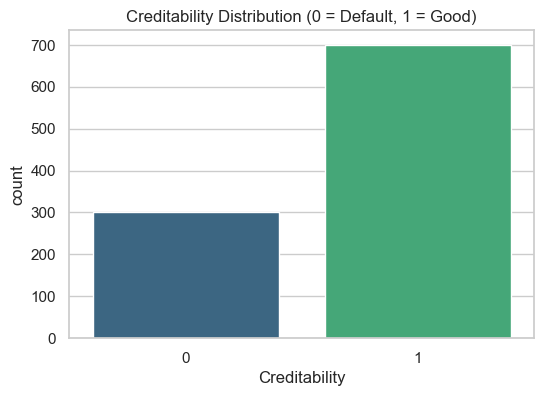

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Creditability', palette='viridis')
plt.title('Creditability Distribution (0 = Default, 1 = Good)')
plt.savefig('../images/target_distribution.png')
plt.show()

In [7]:
TARGET_COL = 'Creditability'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [10]:
joblib.dump(scaler, '../models/scaler.pkl')
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Preprocessed data and scaler successfully saved.")

Preprocessed data and scaler successfully saved.
